# Notebook 02 — Case Representation
## CBR untuk Putusan Pidana Penadahan

**Tujuan Notebook ini:**
1. Load data dari output Notebook 01 (`data/processed/cases.csv`)
2. Ekstrak metadata dari teks putusan (regex)
3. Ekstrak konten kunci: `ringkasan_fakta` dan `amar_putusan`
4. Feature Engineering: `text_length`, `word_count`, `unique_words`
5. Label Preparation: kolom `putusan` (Ringan / Sedang / Berat)
6. Analisis distribusi label
7. Simpan dataset final ke `data/processed/cases.csv`

> **Catatan:** Notebook ini TIDAK mengulang proses PDF → TXT. Proses tersebut sudah selesai di Notebook 01.

---
## Cell 1 — Import Library
Mengimpor semua library yang dibutuhkan.

In [1]:
import pandas as pd
import numpy as np
import re
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore')

print("✅ Library berhasil diimport.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

✅ Library berhasil diimport.
   pandas  : 2.2.3
   numpy   : 2.1.3


---
## Cell 2 — Konfigurasi Path
Mendefinisikan path file input dan output agar mudah diubah jika struktur folder berubah.

In [6]:


import os

# Jika notebook berada di folder:
# CBR_PENADAHAN/notebooks/

BASE_DIR = os.path.abspath(
    os.path.join(os.getcwd(), "..")
)

INPUT_CSV = os.path.join(
    BASE_DIR,
    "data",
    "processed",
    "cases.csv"
)

OUTPUT_CSV = os.path.join(
    BASE_DIR,
    "data",
    "processed",
    "cases.csv"
)

print(f"📁 BASE_DIR   : {BASE_DIR}")
print(f"📄 INPUT_CSV  : {INPUT_CSV}")
print(f"💾 OUTPUT_CSV : {OUTPUT_CSV}")

# Validasi file
assert os.path.exists(INPUT_CSV), (
    f"❌ File tidak ditemukan:\n{INPUT_CSV}\n\n"
    "Pastikan Notebook 01 sudah berhasil membuat cases.csv"
)

print("\n✅ File input ditemukan.")

📁 BASE_DIR   : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN
📄 INPUT_CSV  : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/processed/cases.csv
💾 OUTPUT_CSV : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/processed/cases.csv

✅ File input ditemukan.


---
## Cell 3 — Load Data dari Notebook 01
Membaca `cases.csv` yang dihasilkan Notebook 01. Kolom minimal yang dibutuhkan: `case_id`, `file_name`, `text_full`.

In [7]:
df = pd.read_csv(INPUT_CSV)

print(f"📊 Jumlah putusan   : {len(df)}")
print(f"📋 Kolom yang ada   : {list(df.columns)}")

# Validasi kolom wajib
required_cols = {'case_id', 'file_name', 'text_full'}
missing = required_cols - set(df.columns)
assert not missing, (
    f"❌ Kolom berikut tidak ditemukan di CSV: {missing}\n"
    "   Periksa output Notebook 01."
)

# Pastikan text_full tidak semua kosong
empty_text = df['text_full'].isna().sum()
print(f"\n⚠️  Baris dengan text_full kosong : {empty_text}")

# Tampilkan sample
df[['case_id', 'file_name']].head(5)

📊 Jumlah putusan   : 50
📋 Kolom yang ada   : ['case_id', 'file_name', 'txt_file', 'status', 'alasan_gagal', 'len_raw', 'len_clean', 'text_full']

⚠️  Baris dengan text_full kosong : 0


,case_id,file_name
0,case_001,case_001.pdf
1,case_002,case_002.pdf
2,case_003,case_003.pdf
3,case_004,case_004.pdf
4,case_005,case_005.pdf


---
## Cell 4 — Fungsi Helper Regex
Mendefinisikan fungsi-fungsi regex yang akan digunakan untuk mengekstrak metadata.
Setiap fungsi **aman** — mengembalikan `None` jika pola tidak ditemukan, tidak menyebabkan error.

In [8]:
def safe_search(pattern: str, text: str, group: int = 1, flags=re.IGNORECASE | re.DOTALL):
    """Cari pola regex; kembalikan group jika ditemukan, else None."""
    if not isinstance(text, str):
        return None
    m = re.search(pattern, text, flags)
    if m:
        try:
            return m.group(group).strip()
        except IndexError:
            return None
    return None


def extract_nomor_perkara(text: str):
    """
    Pola nomor perkara pidana Indonesia:
    Contoh: 'Nomor 123/Pid.B/2023/PN.Mlg'
    """
    patterns = [
        r'(?:Nomor|No\.?|NOMOR)\s*[:\.\-]?\s*([\d]+\s*/\s*Pid[^\s,;]+)',
        r'(?:Nomor|No\.?|NOMOR)\s*[:\.\-]?\s*([\d]+\s*/\s*[A-Z][^\s,;]+)',
        r'(\d+\s*/\s*Pid\.\w+\s*/\s*\d{4}\s*/\s*PN\.\w+)',
    ]
    for p in patterns:
        result = safe_search(p, text)
        if result:
            # bersihkan spasi dalam nomor
            return re.sub(r'\s+', '', result)
    return None


def extract_pasal(text: str):
    """
    Ekstrak pasal yang didakwakan.
    Contoh: 'Pasal 480 KUHP', 'Pasal 480 ayat (1) KUHP'
    """
    patterns = [
        r'(?:Pasal|PASAL)\s*(\d+(?:\s+ayat\s*\([^)]+\))?(?:\s+(?:jo\.?|dan|atau)\s+Pasal\s+\d+)*)\s*(?:KUH[HP]|KUHP|KUH\.?P)',
        r'(?:Pasal|PASAL)\s*(480[^\n]{0,60})',
        r'(?:dakwaan|didakwa).*?(Pasal\s+\d+[^\n]{0,80})',
    ]
    for p in patterns:
        result = safe_search(p, text)
        if result:
            return result[:120]  # batasi panjang
    return None


def extract_tanggal_putusan(text: str):
    """
    Ekstrak tanggal putusan.
    Contoh: 'diputuskan pada hari Senin, tanggal 12 Januari 2023'
    """
    BULAN = (
        r'(?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|'
        r'September|Oktober|November|Desember)'
    )
    patterns = [
        rf'(?:tanggal|pada tanggal|tgl\.?)\s*(\d{{1,2}}\s+{BULAN}\s+\d{{4}})',
        rf'(\d{{1,2}}\s+{BULAN}\s+\d{{4}})(?=.*(?:putus|hakim|majelis))',
        rf'(\d{{1,2}}\s+{BULAN}\s+\d{{4}})',  # fallback: tanggal apapun
    ]
    for p in patterns:
        result = safe_search(p, text)
        if result:
            return result
    return None


def extract_jenis_perkara(text: str):
    """
    Deteksi jenis perkara dari kata kunci.
    Untuk dataset ini hampir pasti 'Pidana Biasa'.
    """
    mapping = {
        r'Pid\.Sus': 'Pidana Khusus',
        r'Pid\.B': 'Pidana Biasa',
        r'penadahan': 'Pidana Penadahan',
        r'tindak pidana': 'Pidana',
    }
    for pattern, label in mapping.items():
        if safe_search(pattern, text):
            return label
    return 'Pidana'


def extract_terdakwa(text: str):
    """
    Ekstrak nama terdakwa.
    Mencari pola: 'Terdakwa : NAMA LENGKAP' atau 'nama : ...'
    """
    patterns = [
        r'(?:Nama\s*Lengkap|Nama)\s*[:\-]\s*([A-Z][A-Za-z\s]{3,50})',
        r'(?:Terdakwa|TERDAKWA)\s*[:\-]\s*([A-Z][A-Za-z\s]{3,50})',
        r'(?:mengadili|memeriksa).*?(?:terdakwa)\s+(?:bernama\s+)?([A-Z][A-Za-z\s]{3,40})',
    ]
    for p in patterns:
        result = safe_search(p, text)
        if result:
            # Bersihkan trailing kata umum
            result = re.sub(r'\b(?:Bin|Binti|Alias|Als|Tempat|Umur|TTL)\b.*', '', result, flags=re.IGNORECASE)
            result = result.strip()
            if len(result) > 3:
                return result
    return None


print("✅ Fungsi helper regex berhasil didefinisikan.")

✅ Fungsi helper regex berhasil didefinisikan.


---
## Cell 5 — Metadata Extraction
Menerapkan fungsi ekstraksi metadata ke setiap baris DataFrame.
Jika metadata tidak ditemukan, nilai diisi `None` (tidak menyebabkan error).

In [9]:
print("⏳ Mengekstrak metadata dari teks putusan...")

df['nomor_perkara']   = df['text_full'].apply(extract_nomor_perkara)
df['pasal']           = df['text_full'].apply(extract_pasal)
df['tanggal_putusan'] = df['text_full'].apply(extract_tanggal_putusan)
df['jenis_perkara']   = df['text_full'].apply(extract_jenis_perkara)
df['terdakwa']        = df['text_full'].apply(extract_terdakwa)

print("\n📊 Hasil ekstraksi metadata:")
meta_cols = ['nomor_perkara', 'pasal', 'tanggal_putusan', 'jenis_perkara', 'terdakwa']
for col in meta_cols:
    found    = df[col].notna().sum()
    not_found = df[col].isna().sum()
    pct      = found / len(df) * 100
    print(f"   {col:<20}: ditemukan={found:>3} ({pct:.0f}%)  |  tidak ditemukan={not_found}")

print("\n✅ Metadata extraction selesai.")

⏳ Mengekstrak metadata dari teks putusan...

📊 Hasil ekstraksi metadata:
   nomor_perkara       : ditemukan= 50 (100%)  |  tidak ditemukan=0
   pasal               : ditemukan= 50 (100%)  |  tidak ditemukan=0
   tanggal_putusan     : ditemukan= 49 (98%)  |  tidak ditemukan=1
   jenis_perkara       : ditemukan= 50 (100%)  |  tidak ditemukan=0
   terdakwa            : ditemukan= 50 (100%)  |  tidak ditemukan=0

✅ Metadata extraction selesai.


---
## Cell 6 — Key Content Extraction: `ringkasan_fakta`
Mengambil bagian awal putusan (kalimat-kalimat pertama yang relevan) sebagai ringkasan fakta.
Strategi: ambil 5 kalimat pertama atau 800 karakter pertama, mana yang lebih kecil.

In [10]:
def extract_ringkasan_fakta(text: str, max_chars: int = 800) -> str:
    """
    Ambil ringkasan fakta dari teks putusan.
    Strategi:
      1. Cari bagian 'fakta hukum', 'pertimbangan', 'dakwaan'.
      2. Jika tidak ada, ambil 800 karakter pertama.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return None

    # Cari bagian fakta
    markers = [
        r'(?:Menimbang|MENIMBANG).*?(?=\n\n|\nMenimbang|\nMENIMBANG)',
        r'(?:Dakwaan|DAKWAAN|surat dakwaan)([\s\S]{0,800})',
        r'(?:fakta.{0,10}hukum|FAKTA HUKUM)([\s\S]{0,800})',
        r'(?:Terdakwa)[\s\S]{0,600}(?:oleh karena|sehingga|dengan demikian)',
    ]

    for pattern in markers:
        result = safe_search(pattern, text, group=0)
        if result and len(result) > 50:
            return result[:max_chars].strip()

    # Fallback: 800 karakter pertama
    return text[:max_chars].strip()


df['ringkasan_fakta'] = df['text_full'].apply(extract_ringkasan_fakta)

found = df['ringkasan_fakta'].notna().sum()
print(f"✅ ringkasan_fakta berhasil diekstrak: {found}/{len(df)} dokumen")

# Tampilkan contoh
sample = df['ringkasan_fakta'].dropna().iloc[0]
print(f"\n📄 Contoh ringkasan_fakta (100 karakter pertama):")
print(f"   {repr(sample[:150])}")

✅ ringkasan_fakta berhasil diekstrak: 50/50 dokumen

📄 Contoh ringkasan_fakta (100 karakter pertama):
   'menimbang, bahwa putusan pengadilan tinggi banjarmasin tersebut telah diberitahukan kepada penuntut umum pada tanggal 16 desember 2013 dan penuntut um'


---
## Cell 7 — Key Content Extraction: `amar_putusan`
Mengambil bagian amar putusan dari teks, yaitu bagian yang mengandung kalimat hukuman.
Kata kunci: `menjatuhkan pidana`, `menghukum terdakwa`, `pidana penjara`, `pidana kurungan`.

In [11]:
def extract_amar_putusan(text: str, max_chars: int = 600) -> str:
    """
    Ekstrak amar putusan dari teks.
    Mencari paragraf yang mengandung kata kunci hukuman.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return None

    # Pola amar putusan — urutan dari yang paling spesifik
    patterns = [
        # Blok setelah 'M E N G A D I L I' atau 'MENGADILI'
        r'(?:M\s*E\s*N\s*G\s*A\s*D\s*I\s*L\s*I|MENGADILI)[:\s]*([\s\S]{0,600}?)(?=\n\n|Demikian|Ditetapkan|\Z)',
        # Paragraf mengandung 'menjatuhkan pidana'
        r'(menjatuhkan pidana[\s\S]{0,500}?)(?=\n\n|\Z)',
        # Paragraf mengandung 'menghukum terdakwa'
        r'(menghukum terdakwa[\s\S]{0,500}?)(?=\n\n|\Z)',
        # 'pidana penjara' atau 'pidana kurungan'
        r'((?:pidana penjara|pidana kurungan)[\s\S]{0,400}?)(?=\n\n|\Z)',
    ]

    for pattern in patterns:
        result = safe_search(pattern, text, group=1)
        if result and len(result.strip()) > 20:
            return result.strip()[:max_chars]

    return None


df['amar_putusan'] = df['text_full'].apply(extract_amar_putusan)

found     = df['amar_putusan'].notna().sum()
not_found = df['amar_putusan'].isna().sum()
print(f"✅ amar_putusan berhasil diekstrak: {found}/{len(df)} dokumen")
if not_found > 0:
    print(f"⚠️  {not_found} dokumen tidak memiliki amar_putusan — akan diisi None.")
    # Tampilkan file_name yang tidak ditemukan
    missing_files = df[df['amar_putusan'].isna()]['file_name'].tolist()
    print(f"   File: {missing_files[:5]}")

✅ amar_putusan berhasil diekstrak: 39/50 dokumen
⚠️  11 dokumen tidak memiliki amar_putusan — akan diisi None.
   File: ['case_003.pdf', 'case_004.pdf', 'case_018.pdf', 'case_023.pdf', 'case_025.pdf']


---
## Cell 8 — Feature Engineering
Membuat fitur numerik dari `text_full`:
- `text_length`: jumlah karakter
- `word_count`: jumlah kata
- `unique_words`: jumlah kata unik (case-insensitive)

In [12]:
def safe_text(text):
    """Kembalikan string kosong jika text bukan str."""
    return text if isinstance(text, str) else ''


df['text_length']  = df['text_full'].apply(lambda x: len(safe_text(x)))
df['word_count']   = df['text_full'].apply(lambda x: len(safe_text(x).split()))
df['unique_words'] = df['text_full'].apply(
    lambda x: len(set(re.findall(r'\b\w+\b', safe_text(x).lower())))
)

print("✅ Feature Engineering selesai.")
print("\n📊 Statistik fitur teks:")
display(df[['text_length', 'word_count', 'unique_words']].describe().round(0))

✅ Feature Engineering selesai.

📊 Statistik fitur teks:


,text_length,word_count,unique_words
count,50.0,50.0,50.0
mean,78430.0,9928.0,1189.0
std,111664.0,14443.0,942.0
min,12651.0,1350.0,466.0
25%,22018.0,2849.0,687.0
50%,42590.0,5228.0,934.0
75%,80612.0,9390.0,1374.0
max,656132.0,85028.0,5788.0


---
## Cell 9 — Label Preparation: Ekstrak Lama Hukuman
Fungsi untuk mengekstrak lama hukuman penjara dari teks putusan, lalu mengonversinya ke bulan.

In [13]:
def extract_lama_hukuman_bulan(text: str):
    """
    Ekstrak lama hukuman penjara/kurungan dari teks putusan.
    Output: lama hukuman dalam bulan (int), atau None jika tidak ditemukan.

    Pola yang dicari:
      - '2 (dua) tahun' → 24 bulan
      - '6 (enam) bulan' → 6 bulan
      - '1 tahun 6 bulan' → 18 bulan
      - '8 bulan' → 8 bulan
      - '3 tahun' → 36 bulan
    """
    if not isinstance(text, str):
        return None

    # Kata bilangan Indonesia → angka
    kata_angka = {
        'satu': 1, 'dua': 2, 'tiga': 3, 'empat': 4, 'lima': 5,
        'enam': 6, 'tujuh': 7, 'delapan': 8, 'sembilan': 9, 'sepuluh': 10,
        'sebelas': 11, 'dua belas': 12, 'tiga belas': 13, 'empat belas': 14,
        'lima belas': 15, 'enam belas': 16, 'tujuh belas': 17, 'delapan belas': 18,
        'sembilan belas': 19, 'dua puluh': 20,
    }

    def kata_to_int(s: str):
        """Konversi kata/angka ke int."""
        s = s.strip().lower()
        if s.isdigit():
            return int(s)
        for kata, val in kata_angka.items():
            if kata in s:
                return val
        return None

    # Cari di sekitar kalimat yang mengandung 'pidana penjara' atau 'hukuman'
    # Ambil 1000 karakter setelah kata kunci
    search_area = text
    for kw in ['pidana penjara', 'menghukum', 'menjatuhkan pidana', 'MENGADILI']:
        idx = text.lower().find(kw.lower())
        if idx != -1:
            search_area = text[idx: idx + 1000]
            break

    # Pola: X tahun Y bulan
    p1 = re.search(
        r'(\d+|(?:satu|dua|tiga|empat|lima|enam|tujuh|delapan|sembilan|sepuluh|'
        r'sebelas|dua belas))[^\d]{0,25}?\btahun\b[^\d]{0,25}?'
        r'(\d+|(?:satu|dua|tiga|empat|lima|enam|tujuh|delapan|sembilan|sepuluh|'
        r'sebelas))[^\d]{0,25}?\bbulan\b',
        search_area, re.IGNORECASE
    )
    if p1:
        tahun = kata_to_int(p1.group(1))
        bulan = kata_to_int(p1.group(2))
        if tahun is not None and bulan is not None:
            return tahun * 12 + bulan

    # Pola: X tahun (tanpa bulan)
    p2 = re.search(
        r'(\d+|(?:satu|dua|tiga|empat|lima|enam|tujuh|delapan|sembilan|sepuluh|'
        r'sebelas|dua belas|tiga belas|empat belas|lima belas))[^\d]{0,25}?\btahun\b',
        search_area, re.IGNORECASE
    )
    if p2:
        tahun = kata_to_int(p2.group(1))
        if tahun is not None and tahun <= 20:  # sanity check
            return tahun * 12

    # Pola: X bulan (tanpa tahun)
    p3 = re.search(
        r'(\d+|(?:satu|dua|tiga|empat|lima|enam|tujuh|delapan|sembilan|sepuluh|'
        r'sebelas))[^\d]{0,25}?\bbulan\b',
        search_area, re.IGNORECASE
    )
    if p3:
        bulan = kata_to_int(p3.group(1))
        if bulan is not None and bulan <= 24:  # sanity check
            return bulan

    return None


df['lama_hukuman_bulan'] = df['text_full'].apply(extract_lama_hukuman_bulan)

extracted = df['lama_hukuman_bulan'].notna().sum()
not_found = df['lama_hukuman_bulan'].isna().sum()
print(f"✅ Lama hukuman berhasil diekstrak: {extracted}/{len(df)} dokumen")
if not_found > 0:
    print(f"⚠️  {not_found} dokumen tidak terdeteksi lama hukumannya.")

print("\n📊 Distribusi lama hukuman (dalam bulan):")
print(df['lama_hukuman_bulan'].describe())

✅ Lama hukuman berhasil diekstrak: 49/50 dokumen
⚠️  1 dokumen tidak terdeteksi lama hukumannya.

📊 Distribusi lama hukuman (dalam bulan):
count     49.000000
mean      25.326531
std       33.810371
min        3.000000
25%        8.000000
50%       18.000000
75%       30.000000
max      216.000000
Name: lama_hukuman_bulan, dtype: float64


---
## Cell 10 — Label Preparation: Penentuan Threshold & Kategorisasi

Strategi kategori berdasarkan ketentuan hukum pidana Indonesia dan empiris data:

| Kategori | Lama Hukuman |
|---|---|
| **Ringan** | < 12 bulan (< 1 tahun) |
| **Sedang** | 12 – 36 bulan (1 – 3 tahun) |
| **Berat** | > 36 bulan (> 3 tahun) |

Untuk putusan yang lama hukumannya tidak terdeteksi, kategori ditentukan dengan fallback berbasis kata kunci.

In [14]:
# ── Threshold (dalam bulan) ───────────────────────────────────────────────────
THRESHOLD_RINGAN_MAX = 12   # < 12 bulan = Ringan
THRESHOLD_SEDANG_MAX = 36   # 12–36 bulan = Sedang; > 36 = Berat

print(f"📐 Threshold yang digunakan:")
print(f"   Ringan : < {THRESHOLD_RINGAN_MAX} bulan")
print(f"   Sedang : {THRESHOLD_RINGAN_MAX}–{THRESHOLD_SEDANG_MAX} bulan")
print(f"   Berat  : > {THRESHOLD_SEDANG_MAX} bulan")


def fallback_label_dari_teks(text: str) -> str:
    """
    Fallback: tentukan label berdasarkan kata kunci jika lama hukuman tidak terdeteksi.
    Mengembalikan 'Sedang' sebagai default yang paling netral.
    """
    if not isinstance(text, str):
        return 'Sedang'
    text_lower = text.lower()
    # Indikator Berat: hukuman tinggi, pasal berlapis
    if any(kw in text_lower for kw in ['4 tahun', '5 tahun', '6 tahun', '7 tahun',
                                        'empat tahun', 'lima tahun', 'enam tahun']):
        return 'Berat'
    # Indikator Ringan: bebas, paling ringan, percobaan
    if any(kw in text_lower for kw in ['dibebaskan', 'bebas', '3 bulan', '6 bulan',
                                        'tiga bulan', 'enam bulan', 'percobaan']):
        return 'Ringan'
    return 'Sedang'


def assign_label(row):
    bulan = row['lama_hukuman_bulan']
    if pd.isna(bulan):
        return fallback_label_dari_teks(row['text_full'])
    bulan = int(bulan)
    if bulan < THRESHOLD_RINGAN_MAX:
        return 'Ringan'
    elif bulan <= THRESHOLD_SEDANG_MAX:
        return 'Sedang'
    else:
        return 'Berat'


df['putusan'] = df.apply(assign_label, axis=1)

print("\n✅ Label 'putusan' berhasil dibuat.")

📐 Threshold yang digunakan:
   Ringan : < 12 bulan
   Sedang : 12–36 bulan
   Berat  : > 36 bulan

✅ Label 'putusan' berhasil dibuat.


---
## Cell 11 — Analisis Distribusi Label
Menampilkan distribusi label dan memberikan **warning** jika distribusi sangat tidak seimbang.

In [15]:
# ── Hitung distribusi ─────────────────────────────────────────────────────────
dist = df['putusan'].value_counts()
dist_pct = df['putusan'].value_counts(normalize=True) * 100

print("📊 Distribusi Label Putusan:")
print(f"{'Label':<10} {'Jumlah':>8} {'Persentase':>12}")
print("-" * 32)
for label in dist.index:
    print(f"{label:<10} {dist[label]:>8} {dist_pct[label]:>11.1f}%")
print("-" * 32)
print(f"{'TOTAL':<10} {len(df):>8} {'100.0':>11}%")

# ── Warning imbalance ─────────────────────────────────────────────────────────
min_pct = dist_pct.min()
max_pct = dist_pct.max()
ratio   = max_pct / (min_pct if min_pct > 0 else 1)

print()
if min_pct < 10:
    print("⚠️  WARNING: Distribusi label sangat tidak seimbang!")
    print(f"   Label terkecil hanya {min_pct:.1f}% dari total data.")
    print("   Rekomendasi: Pertimbangkan penyesuaian threshold THRESHOLD_RINGAN_MAX")
    print("   dan THRESHOLD_SEDANG_MAX di Cell 10 berdasarkan distribusi aktual data.")
    print("   Jangan memaksakan keseimbangan — label harus realistis dari isi putusan.")
elif ratio > 5:
    print(f"⚠️  WARNING: Rasio label terbesar/terkecil = {ratio:.1f}x (cukup timpang).")
    print("   Pertimbangkan review threshold jika akurasi model nanti rendah.")
else:
    print(f"✅ Distribusi label dalam batas wajar (rasio max/min = {ratio:.1f}x).")

print(f"\n📋 Lama hukuman tidak terdeteksi: {df['lama_hukuman_bulan'].isna().sum()} putusan")
print("   Label untuk putusan ini ditentukan via fallback kata kunci.")

📊 Distribusi Label Putusan:
Label        Jumlah   Persentase
--------------------------------
Sedang           27        54.0%
Ringan           16        32.0%
Berat             7        14.0%
--------------------------------
TOTAL            50       100.0%

✅ Distribusi label dalam batas wajar (rasio max/min = 3.9x).

📋 Lama hukuman tidak terdeteksi: 1 putusan
   Label untuk putusan ini ditentukan via fallback kata kunci.


---
## Cell 12 — Visualisasi Distribusi Label
Bar chart distribusi label menggunakan matplotlib.

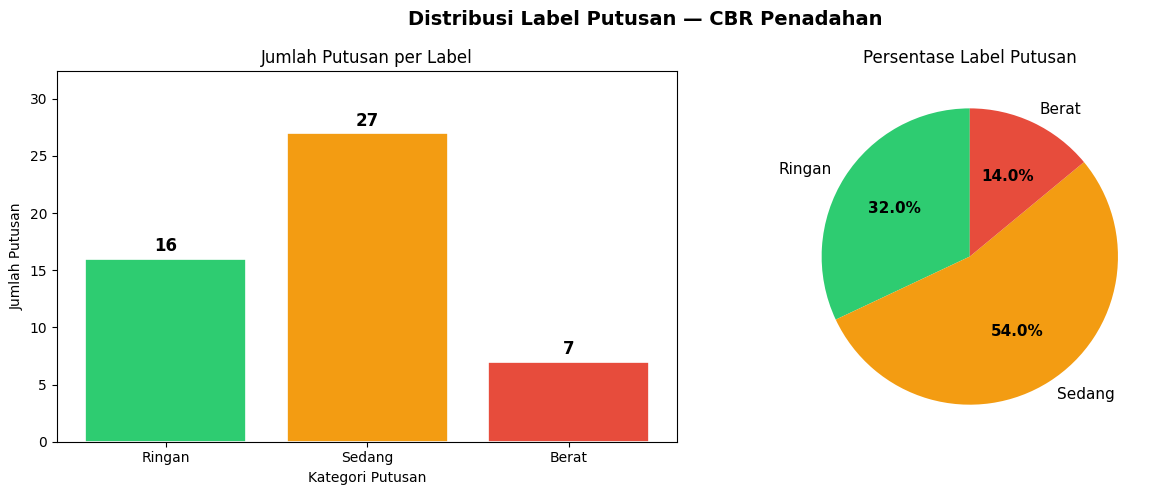

✅ Chart disimpan ke data/processed/label_distribution.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribusi Label Putusan — CBR Penadahan', fontsize=14, fontweight='bold')

# ── Bar chart ─────────────────────────────────────────────────────────────────
colors = {'Ringan': '#2ecc71', 'Sedang': '#f39c12', 'Berat': '#e74c3c'}
labels_order = [l for l in ['Ringan', 'Sedang', 'Berat'] if l in dist.index]
counts  = [dist.get(l, 0) for l in labels_order]
bar_col = [colors.get(l, '#3498db') for l in labels_order]

bars = axes[0].bar(labels_order, counts, color=bar_col, edgecolor='white', linewidth=1.2)
axes[0].set_title('Jumlah Putusan per Label', fontsize=12)
axes[0].set_xlabel('Kategori Putusan')
axes[0].set_ylabel('Jumlah Putusan')
axes[0].set_ylim(0, max(counts) * 1.2)

for bar, count in zip(bars, counts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(count),
        ha='center', va='bottom', fontweight='bold', fontsize=12
    )

# ── Pie chart ─────────────────────────────────────────────────────────────────
pie_pct  = [dist_pct.get(l, 0) for l in labels_order]
pie_col  = [colors.get(l, '#3498db') for l in labels_order]

wedges, texts, autotexts = axes[1].pie(
    pie_pct, labels=labels_order, autopct='%1.1f%%',
    colors=pie_col, startangle=90,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Persentase Label Putusan', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'data', 'processed', 'label_distribution.png'),
            dpi=100, bbox_inches='tight')
plt.show()
print("✅ Chart disimpan ke data/processed/label_distribution.png")

---
## Cell 13 — Tampilkan Distribusi Lama Hukuman
Histogram lama hukuman dalam bulan untuk memvalidasi threshold yang digunakan.

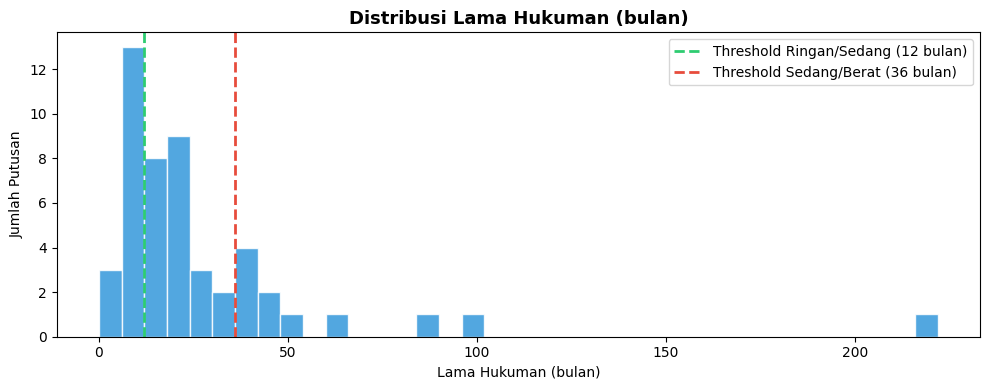


📊 Statistik lama hukuman yang terdeteksi (49 putusan):
   Min    : 3 bulan
   Median : 18 bulan
   Max    : 216 bulan
   Mean   : 25.3 bulan


In [17]:
hukuman_data = df['lama_hukuman_bulan'].dropna()

if len(hukuman_data) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.hist(hukuman_data, bins=range(0, int(hukuman_data.max()) + 7, 6),
            color='#3498db', edgecolor='white', alpha=0.85)

    # Garis threshold
    ax.axvline(THRESHOLD_RINGAN_MAX, color='#2ecc71', linestyle='--', lw=2,
               label=f'Threshold Ringan/Sedang ({THRESHOLD_RINGAN_MAX} bulan)')
    ax.axvline(THRESHOLD_SEDANG_MAX, color='#e74c3c', linestyle='--', lw=2,
               label=f'Threshold Sedang/Berat ({THRESHOLD_SEDANG_MAX} bulan)')

    ax.set_title('Distribusi Lama Hukuman (bulan)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Lama Hukuman (bulan)')
    ax.set_ylabel('Jumlah Putusan')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n📊 Statistik lama hukuman yang terdeteksi ({len(hukuman_data)} putusan):")
    print(f"   Min    : {hukuman_data.min():.0f} bulan")
    print(f"   Median : {hukuman_data.median():.0f} bulan")
    print(f"   Max    : {hukuman_data.max():.0f} bulan")
    print(f"   Mean   : {hukuman_data.mean():.1f} bulan")
else:
    print("⚠️  Tidak ada data lama hukuman yang berhasil diekstrak untuk divisualisasikan.")

---
## Cell 14 — Susun Kolom Final & Preview
Menyusun ulang kolom sesuai spesifikasi dan menampilkan preview dataset final.

In [18]:
# ── Kolom yang wajib ada ──────────────────────────────────────────────────────
FINAL_COLS = [
    'case_id',
    'file_name',
    'nomor_perkara',
    'tanggal_putusan',
    'jenis_perkara',
    'pasal',
    'terdakwa',
    'ringkasan_fakta',
    'amar_putusan',
    'text_length',
    'word_count',
    'unique_words',
    'putusan',
    'text_full',
]

# Tambahkan kolom lain yang ada di df tapi tidak ada di FINAL_COLS
extra_cols = [c for c in df.columns if c not in FINAL_COLS]
if extra_cols:
    print(f"ℹ️  Kolom tambahan (dari Notebook 01): {extra_cols}")

# Pastikan semua FINAL_COLS ada di df (buat jika tidak ada)
for col in FINAL_COLS:
    if col not in df.columns:
        df[col] = None
        print(f"⚠️  Kolom '{col}' tidak ditemukan — diisi None.")

# Susun kolom final (tambahkan extra_cols di akhir, kecuali lama_hukuman_bulan — disimpan)
FINAL_COLS_EXTENDED = FINAL_COLS + [c for c in extra_cols if c != 'lama_hukuman_bulan']
df_final = df[FINAL_COLS_EXTENDED].copy()

print(f"\n✅ Dataset final tersusun: {df_final.shape[0]} baris × {df_final.shape[1]} kolom")
print(f"   Kolom: {list(df_final.columns)}")

# Preview
print("\n📋 Preview 3 baris pertama:")
display(df_final[['case_id', 'file_name', 'nomor_perkara', 'tanggal_putusan',
                   'pasal', 'text_length', 'word_count', 'putusan']].head(3))

ℹ️  Kolom tambahan (dari Notebook 01): ['txt_file', 'status', 'alasan_gagal', 'len_raw', 'len_clean', 'lama_hukuman_bulan']

✅ Dataset final tersusun: 50 baris × 19 kolom
   Kolom: ['case_id', 'file_name', 'nomor_perkara', 'tanggal_putusan', 'jenis_perkara', 'pasal', 'terdakwa', 'ringkasan_fakta', 'amar_putusan', 'text_length', 'word_count', 'unique_words', 'putusan', 'text_full', 'txt_file', 'status', 'alasan_gagal', 'len_raw', 'len_clean']

📋 Preview 3 baris pertama:


,case_id,file_name,nomor_perkara,tanggal_putusan,pasal,text_length,word_count,putusan
0,case_001,case_001.pdf,250/pid.b/,12 mei 2013,480 ke -1 kuhpidana .mahkamah agung tersebut ;...,20146,2732,Sedang
1,case_002,case_002.pdf,103/pid.b/2014/pn,20 oktober 2014,480,34221,4678,Berat
2,case_003,case_003.pdf,15/pid.b/2023/pn,3 desember 2022,480 ayat (1),82285,10733,Ringan


---
## Cell 15 — Validasi Kelengkapan Dataset
Menampilkan ringkasan nilai yang terisi dan kosong untuk setiap kolom.

In [19]:
print("📊 Ringkasan Kelengkapan Dataset Final:")
print(f"{'Kolom':<22} {'Terisi':>8} {'Kosong':>8} {'% Terisi':>10}")
print("-" * 52)

for col in FINAL_COLS:
    filled  = df_final[col].notna().sum()
    empty   = df_final[col].isna().sum()
    pct     = filled / len(df_final) * 100
    status  = '✅' if pct >= 80 else ('⚠️ ' if pct >= 50 else '❌')
    print(f"{status} {col:<20} {filled:>8} {empty:>8} {pct:>9.1f}%")

print("-" * 52)

# Pastikan kolom kritis tidak kosong
critical = ['case_id', 'file_name', 'text_full', 'putusan', 'text_length', 'word_count']
for col in critical:
    null_count = df_final[col].isna().sum()
    assert null_count == 0, (
        f"❌ Kolom kritis '{col}' memiliki {null_count} nilai kosong!"
    )

print("\n✅ Semua kolom kritis terisi penuh.")

📊 Ringkasan Kelengkapan Dataset Final:
Kolom                    Terisi   Kosong   % Terisi
----------------------------------------------------
✅ case_id                    50        0     100.0%
✅ file_name                  50        0     100.0%
✅ nomor_perkara              50        0     100.0%
✅ tanggal_putusan            49        1      98.0%
✅ jenis_perkara              50        0     100.0%
✅ pasal                      50        0     100.0%
✅ terdakwa                   50        0     100.0%
✅ ringkasan_fakta            50        0     100.0%
⚠️  amar_putusan               39       11      78.0%
✅ text_length                50        0     100.0%
✅ word_count                 50        0     100.0%
✅ unique_words               50        0     100.0%
✅ putusan                    50        0     100.0%
✅ text_full                  50        0     100.0%
----------------------------------------------------

✅ Semua kolom kritis terisi penuh.


---
## Cell 16 — Simpan Dataset Final
Menyimpan dataset yang sudah diproses ke `data/processed/cases.csv`.

In [20]:
# Simpan
df_final.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')

# Verifikasi
df_check = pd.read_csv(OUTPUT_CSV)

print("💾 Dataset final berhasil disimpan!")
print(f"   Path     : {OUTPUT_CSV}")
print(f"   Baris    : {len(df_check)}")
print(f"   Kolom    : {len(df_check.columns)}")
print(f"   Encoding : UTF-8 with BOM (utf-8-sig)")

# Verifikasi label tersimpan
print(f"\n📊 Distribusi label dalam file tersimpan:")
print(df_check['putusan'].value_counts().to_string())

💾 Dataset final berhasil disimpan!
   Path     : /Users/asfaahmad/Codingan/Semester 6/Penalaran Komputer/CBR_PENADAHAN/data/processed/cases.csv
   Baris    : 50
   Kolom    : 19
   Encoding : UTF-8 with BOM (utf-8-sig)

📊 Distribusi label dalam file tersimpan:
putusan
Sedang    27
Ringan    16
Berat      7


---
## Cell 17 — Ringkasan Akhir Notebook 02
Laporan singkat apa yang telah dikerjakan dan output yang dihasilkan.

In [21]:
print("=" * 60)
print("  RINGKASAN NOTEBOOK 02 — CASE REPRESENTATION")
print("  CBR Putusan Pidana Penadahan")
print("=" * 60)

print(f"\n📂 Input  : data/processed/cases.csv (dari Notebook 01)")
print(f"💾 Output : data/processed/cases.csv (diperbarui)")
print(f"📊 Chart  : data/processed/label_distribution.png")

print(f"\n📋 Proses yang dilakukan:")
proses = [
    ("A", "Load Data",         "Membaca cases.csv dari Notebook 01"),
    ("B", "Metadata Extraction","nomor_perkara, pasal, tanggal, jenis_perkara, terdakwa"),
    ("C", "Key Content",       "ringkasan_fakta, amar_putusan"),
    ("D", "Feature Engineering","text_length, word_count, unique_words"),
    ("E", "Label Preparation", "kolom 'putusan': Ringan / Sedang / Berat"),
    ("F", "Analisis Distribusi","bar chart + pie chart distribusi label"),
    ("G", "Simpan Dataset",    "cases.csv final dengan semua kolom"),
]
for step, nama, keterangan in proses:
    print(f"   [{step}] {nama:<22} → {keterangan}")

print(f"\n📊 Distribusi Label Final:")
for label, count in df_final['putusan'].value_counts().items():
    pct = count / len(df_final) * 100
    bar = '█' * int(pct / 5)
    print(f"   {label:<8} : {count:>3} putusan ({pct:.1f}%) {bar}")

print(f"\n✅ Notebook 02 selesai. Dataset siap untuk Tahap 3 Retrieval.")
print("=" * 60)

  RINGKASAN NOTEBOOK 02 — CASE REPRESENTATION
  CBR Putusan Pidana Penadahan

📂 Input  : data/processed/cases.csv (dari Notebook 01)
💾 Output : data/processed/cases.csv (diperbarui)
📊 Chart  : data/processed/label_distribution.png

📋 Proses yang dilakukan:
   [A] Load Data              → Membaca cases.csv dari Notebook 01
   [B] Metadata Extraction    → nomor_perkara, pasal, tanggal, jenis_perkara, terdakwa
   [C] Key Content            → ringkasan_fakta, amar_putusan
   [D] Feature Engineering    → text_length, word_count, unique_words
   [E] Label Preparation      → kolom 'putusan': Ringan / Sedang / Berat
   [F] Analisis Distribusi    → bar chart + pie chart distribusi label
   [G] Simpan Dataset         → cases.csv final dengan semua kolom

📊 Distribusi Label Final:
   Sedang   :  27 putusan (54.0%) ██████████
   Ringan   :  16 putusan (32.0%) ██████
   Berat    :   7 putusan (14.0%) ██

✅ Notebook 02 selesai. Dataset siap untuk Tahap 3 Retrieval.
